In [1137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [1138]:
def get_third_harmonic_bin(i, nfft):
    """
    Finds the 3rd harmonic bin for a real-valued signal.
    i: fundamental bin index
    nfft: total number of FFT points
    """
    # Step 1: Wrap around the sampling frequency
    wrapped_bin = (3 * i) % nfft
    
    # Step 2: Fold back if it's above Nyquist
    if wrapped_bin > nfft // 2:
        harmonic_bin = nfft - wrapped_bin
    else:
        harmonic_bin = wrapped_bin
        
    return int(harmonic_bin)

In [1139]:
df = pd.read_csv('./xschem/simulation/tb_th_boot_ota.txt', sep='\\s+')
df

,time,v(vop)
0,4.050000e-09,0.357975
1,6.050000e-09,0.394198
2,8.050000e-09,0.426798
3,1.005000e-08,0.454527
4,1.205000e-08,0.476317
...,...,...
550,6.805000e-08,0.113368
551,7.005000e-08,0.472120
552,7.205000e-08,0.148960
553,7.405000e-08,0.424115


In [1140]:
# Parameters
nfft = 32
pad = 5
bins = np.arange(1, nfft//2)
n = nfft + pad
v = np.reshape(df['v(vop)'].values, [len(df)//n, n])

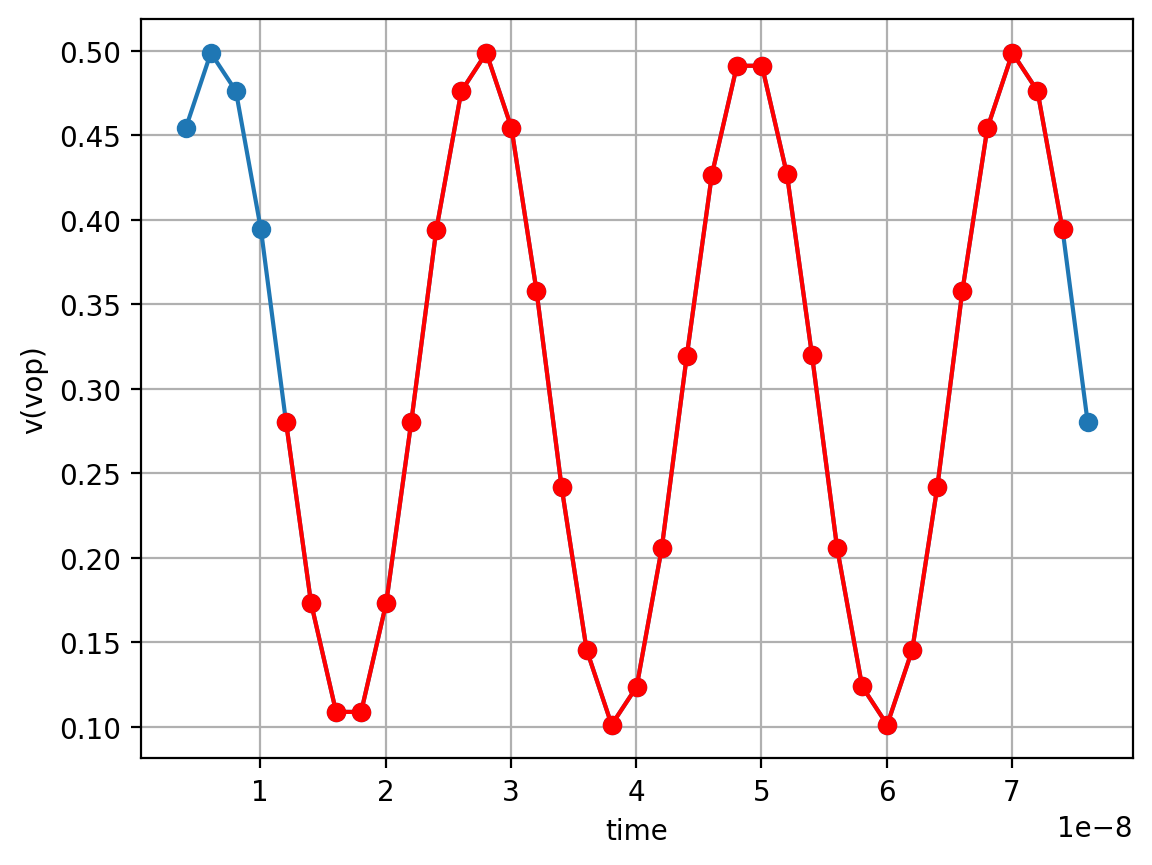

In [1141]:
# Example plot
plt.rcParams['figure.dpi'] = 200
bin = 3
t = df['time']
t = t[0:n]
y = v[bin-1, :]
t1 = t[-nfft-1:-1]
y1 = y[-nfft-1:-1]
plt.plot(t, y, "-o")
plt.plot(t1, y1, "r-o")
plt.grid()
plt.ylabel("v(vop)")
plt.xlabel("time")
plt.show()

In [1142]:
# Remove last point since it's off the sampling grid
y = y[:-1]
print(len(y))

# Check periodicity/steady state by comparing the last valid sample of the FFT window with one right before the window
relative_error = (y[-1]-y[-1-nfft])/y[-1]
print(relative_error)

36
9.949345480460675e-06


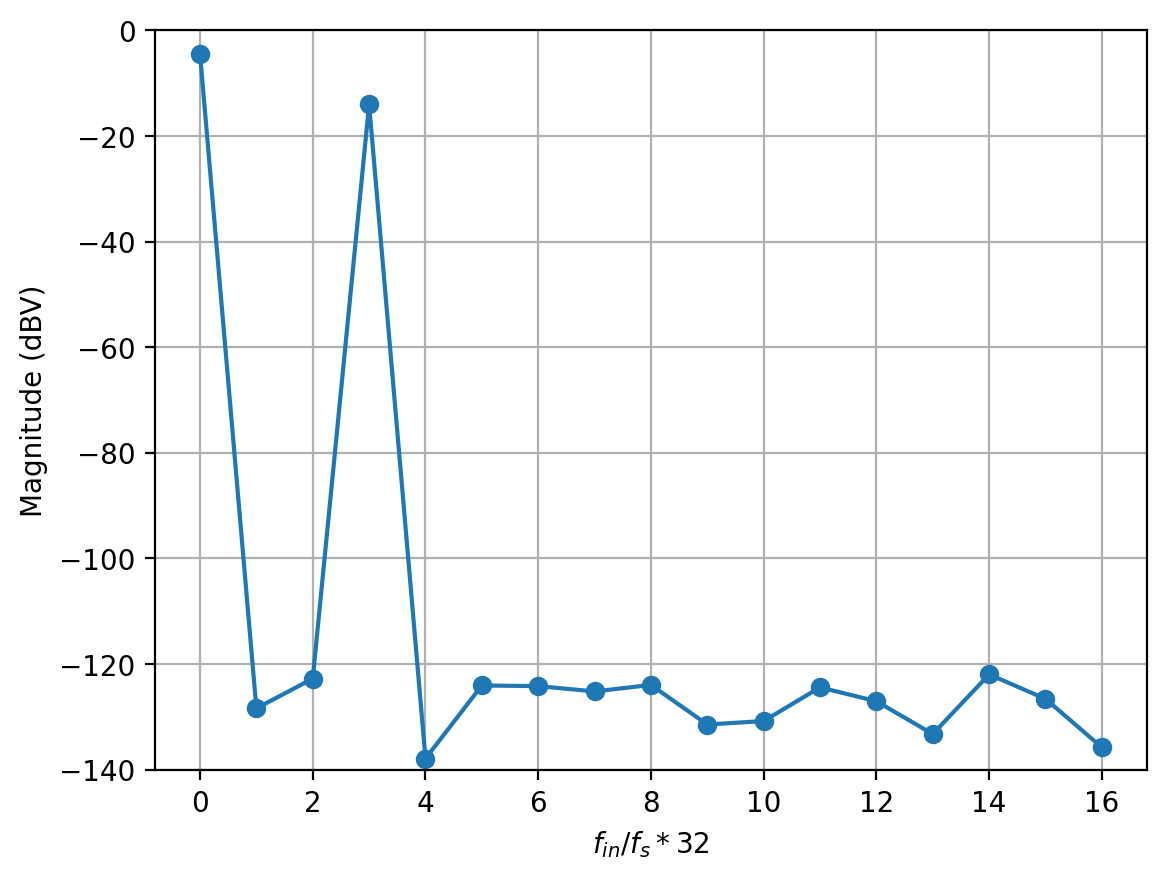

In [1143]:
# Example spectrum
y = y[-nfft:]
spec = np.fft.rfft(y)
spec_dbv = 20*np.log10(np.abs(spec)/(nfft/2))
plt.plot(spec_dbv, "-o")
plt.grid()
plt.xlabel("$f_{in}/f_s*32$")
plt.ylabel("Magnitude (dBV)")
plt.ylim([-140, 0])
plt.show()

In [1144]:
print(spec_dbv)

[  -4.43731958 -128.38637761 -122.77125114  -13.99036763 -137.90022448
 -124.06035604 -124.17966129 -125.18952654 -123.95438548 -131.45713327
 -130.79260452 -124.41814772 -127.04676222 -133.25429713 -121.96534102
 -126.59548533 -135.78293269]


In [1145]:
# SFDR and HD3 for all input frequencies
sfdr = np.zeros(len(bins))
hd3 = np.zeros(len(bins))
for i in bins:
    y = v[i-1, :]
    #y = y[:-3]
    relative_error = (y[-1]-y[-1-nfft])/y[-1]
    print(relative_error)
    y = y[-nfft:]
    spec = np.fft.rfft(y)
    spec_dbv = 20*np.log10(np.abs(spec)/(nfft))
    sfdr[i-1] = spec_dbv[i] - np.max(np.delete(spec_dbv, [0, i]))
    hd3[i-1] = spec_dbv[i] - spec_dbv[get_third_harmonic_bin(i, nfft)]

# remove bin 7 data since it has distortion aliases on top of signal
sfdr = np.delete(sfdr, [nfft//4-1])
hd3 = np.delete(hd3, [nfft//4-1])
bins = np.delete(bins, [nfft//4-1])

# save for plotting
np.savez('pp_tb_th_boot_ota_ideal.npz', sfdr=sfdr, hd3=hd3, bins=bins)

4.975677920875391e-07
-2.166213655320358e-06
-1.3450938109596085e-05
4.001691773589962e-06
-4.074880693582671e-06
4.820026885571421e-06
-1.1570039411244966e-06
-6.17931349921613e-06
-3.074422605708054e-05
-3.037601481287621e-05
-3.1806544384186865e-05
-1.6248453393086138e-05
-1.490879881711181e-06
-3.401796984926854e-05
-5.758820020047516e-05


In [1146]:
# Analytical data
vov = 0.73
vm = 0.20
fs = 500e6
nfft = 32
fin = bins*fs/nfft
c = 5e-12
cb = 5e-12
cp = 0.1e-12
gds = 75e-3
fbw=1/(2*np.pi*c/gds)
hd3_calc = -20*np.log10((1/2)*fin/fbw*(vm/vov)**2 *(cp/cb)**2)
print(fbw/1e6)

2387.3241463784298


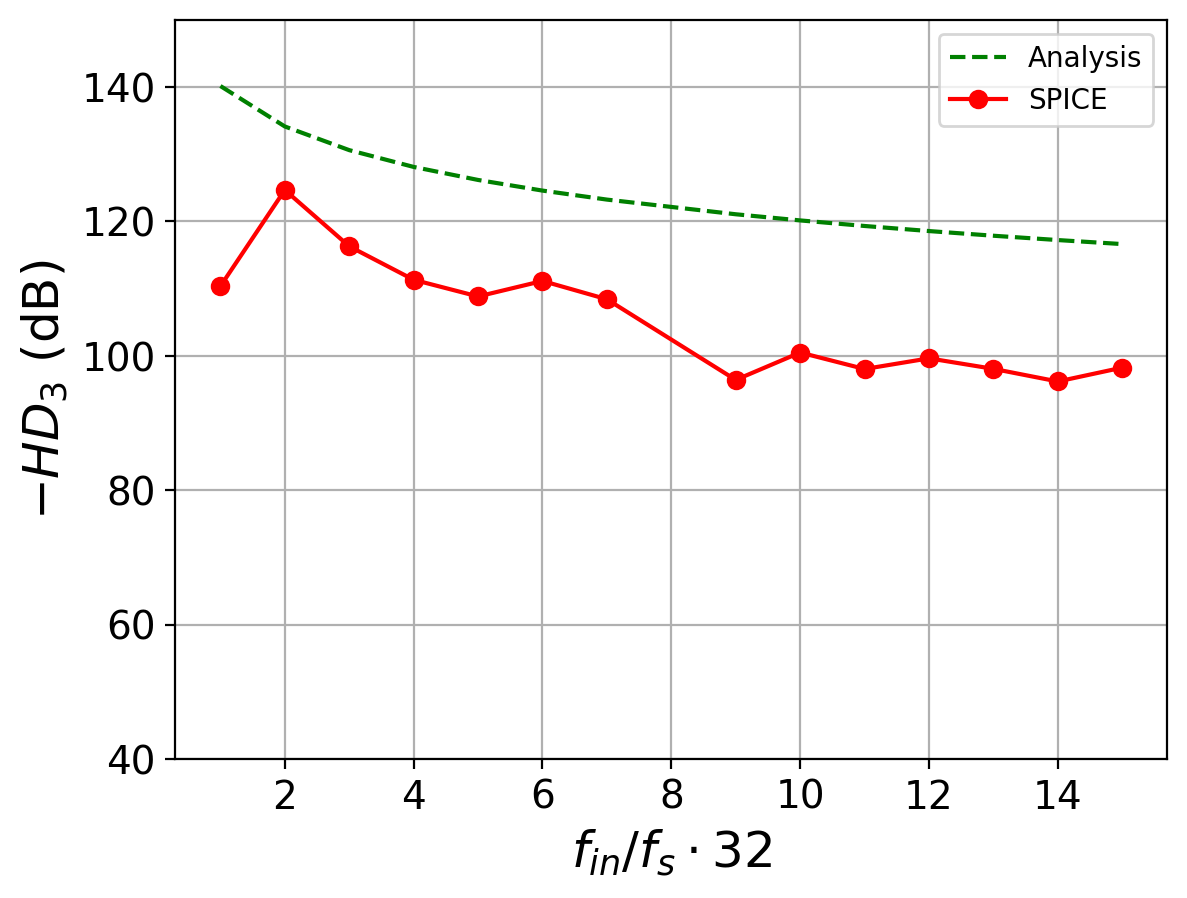

In [1147]:
#plt.rcParams['figure.dpi'] = 200
plt.plot(bins, hd3_calc, "g--", label='Analysis')
plt.plot(bins, hd3, "r-o", label='SPICE')
plt.grid()
plt.xlabel("$f_{in}/f_s \\cdot 32$", fontsize=18)
plt.ylabel("$-HD_3$ (dB)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(40, 150)
plt.grid(True)
plt.legend()
plt.show()